# Deep Learning ile Titanic

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#!pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization

In [4]:
df_test=pd.read_csv('ttrain.csv')
df_train=pd.read_csv('ttrain.csv')

df=pd.concat((df_test,df_train))
df.shape

(1782, 12)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
 df.shape

(1782, 12)

In [7]:
df.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [8]:
df.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             354
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1374
Embarked          4
dtype: int64

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
# Sınıf ve cinsiyete göre yaş medyanını doldurma
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [11]:
# Kabin numarasının ilk harfini al, yoksa 'U' (Unknown) koy
df['Cabin'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S


In [13]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,U,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.45,U,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,U,Q


In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       4
dtype: int64

In [15]:
# Eksik değerleri doldur
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
# One-Hot Encoding uygula (S, C, Q harfleri için ayrı sütunlar oluştur)
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

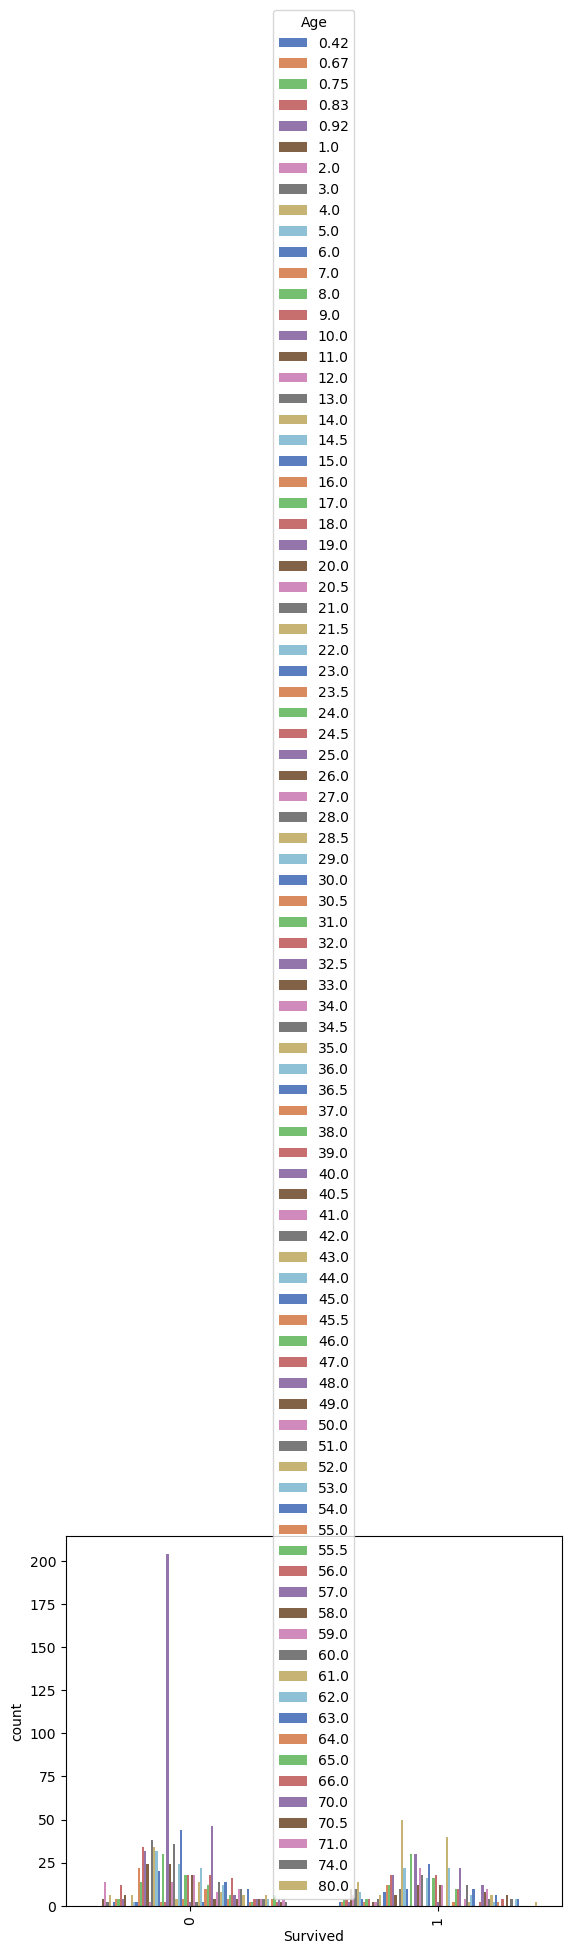

In [17]:
sns.countplot(x=df['Survived'],hue=df['Age'], palette='muted');
plt.xticks(rotation=90);

<Axes: xlabel='Age', ylabel='Density'>

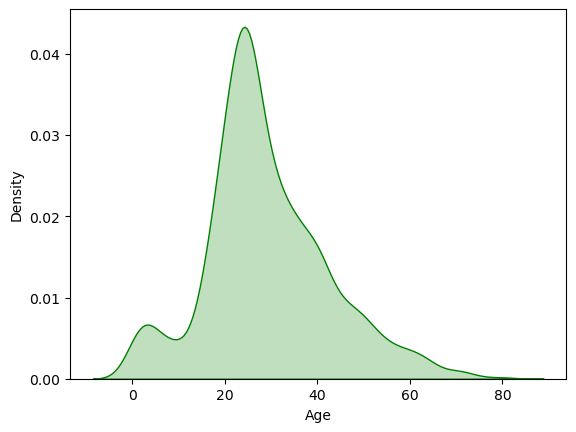

In [18]:
sns.kdeplot(x=df['Age'],fill=True, color='green')

In [19]:
import plotly.express as px

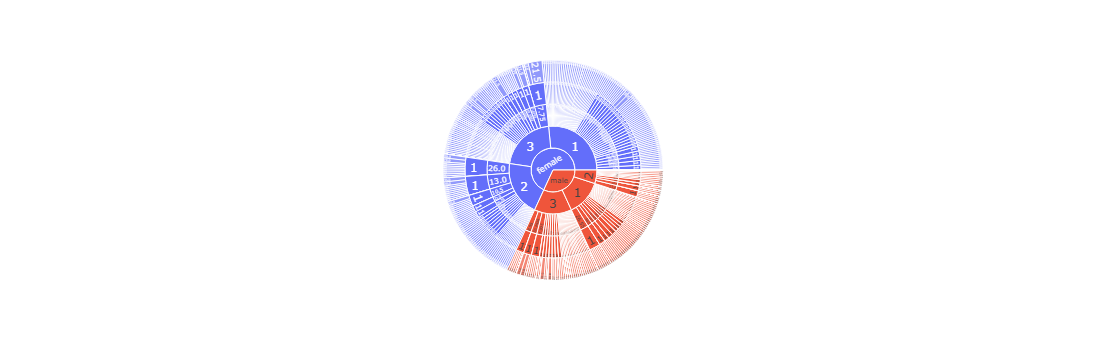

In [20]:
px.sunburst(df, path=['Sex', 'Pclass','Fare', 'Survived','Age'], values='Survived')

<Axes: >

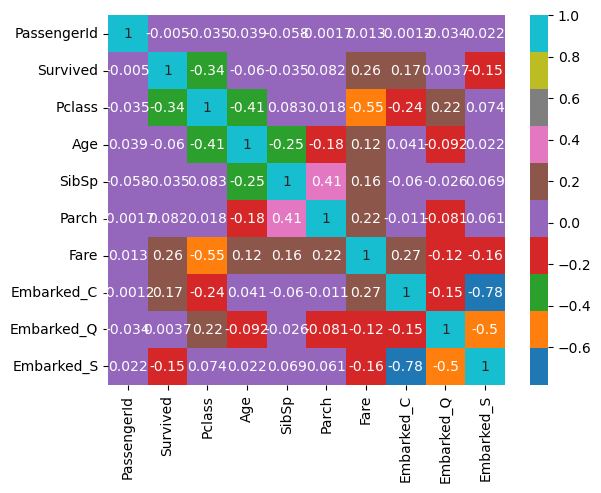

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='tab10')

In [23]:
#x = df[['PassengerId', 'Pclass', 'Age', 'Sex',
       #'Parch', 'Fare',]]
#y = df['Survived']

In [24]:
#df=pd.get_dummies(df,drop_first=True)
#y = df["Survived"]
#x = df.drop("Survived", axis = 1)

In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,False,False,True


In [26]:
#df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
# Alfabetik sıraya göre female=0, male=1 yapar

In [28]:
#df["Sex"] = df["Sex"].fillna(df["Sex"].mean())

In [31]:
#print(x.dtypes)

In [32]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,U,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,U,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,U,False,False,True


In [33]:
# Sadece ilk harfleri alıp onları sayısal kategoriye çeviriyoruz
#df['Cabin'] = pd.factorize(df['Cabin'])[0]

In [34]:
#stilizing # datayı ikiye bölme

In [35]:
x=df.iloc[:,0:8] # 0 dan 8. satıra kadar al
y=df.iloc[:,8]

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [37]:
model=Sequential()
model.add(Dense(80,activation='relu')) # hayal ürünü black box nature of DL #Dense diyince büyün nöronlar birbirne bağlanıyor
model.add(Dense(120,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid')) # classification son layer sigmoid eğer 1-0 ise
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [38]:
print(x.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
dtype: object


In [39]:
#x = x.drop(columns=['Name'])

In [40]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,U,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,U,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,U,False,False,True


In [41]:
# y değişkenine bilet numarası gibi metinler gelmiş, bunu 'Survived' ile düzeltelim
y = df['Survived'] 

# x değişkeni ise sadece sayısal özellikler olmalı (Survived ve metinler olmamalı)
x = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'], errors='ignore')
x = x.select_dtypes(exclude=['object']) # Garanti olsun diye tüm metinleri atalım


In [42]:
x_train_fix = np.asarray(x).astype('float32')
y_train_fix = np.asarray(y).astype('float32')

In [43]:
histor=model.fit(x,y,batch_size=32,validation_split=0.10,verbose=2,epochs=1) # validation datayı 2 ye böl #verbose hangi aşamada old# eopchs kaç kez gidip geleceğini söyler

51/51 - 7s - 146ms/step - accuracy: 0.5459 - loss: 1.1192 - val_accuracy: 0.6872 - val_loss: 0.5848


In [44]:
print(x.dtypes)

PassengerId      int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_C        bool
Embarked_Q        bool
Embarked_S        bool
dtype: object


In [45]:
model.summary()  # Modelin özet bilgilerini görüntüleme

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 80)             │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,655 (240.84 KB)

 Trainable params: 20,551 (80.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,104 (160.57 KB)

In [46]:
print(x.applymap(lambda val: isinstance(val, str)).any())

PassengerId    False
Pclass         False
Sex            False
Age            False
SibSp          False
Parch          False
Fare           False
Embarked_C     False
Embarked_Q     False
Embarked_S     False
dtype: bool


In [47]:
loss,accuraracy=model.evaluate(x,y)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6498 - loss: 0.6219


In [48]:
accuraracy

0.6498316526412964

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
scaler=StandardScaler()

In [51]:
x=scaler.fit_transform(x)

In [52]:
history=model.fit(x,y,batch_size=32,validation_split=0.10,verbose=2,epochs=100)

Epoch 1/100
51/51 - 1s - 11ms/step - accuracy: 0.7367 - loss: 0.5641 - val_accuracy: 0.8324 - val_loss: 0.4019
Epoch 2/100
51/51 - 0s - 6ms/step - accuracy: 0.8185 - loss: 0.4248 - val_accuracy: 0.8436 - val_loss: 0.3704
Epoch 3/100
51/51 - 1s - 18ms/step - accuracy: 0.8303 - loss: 0.4105 - val_accuracy: 0.8771 - val_loss: 0.3562
Epoch 4/100
51/51 - 1s - 19ms/step - accuracy: 0.8353 - loss: 0.3933 - val_accuracy: 0.8771 - val_loss: 0.3343
Epoch 5/100
51/51 - 1s - 21ms/step - accuracy: 0.8440 - loss: 0.3843 - val_accuracy: 0.8436 - val_loss: 0.3559
Epoch 6/100
51/51 - 1s - 28ms/step - accuracy: 0.8422 - loss: 0.3776 - val_accuracy: 0.8771 - val_loss: 0.3200
Epoch 7/100
51/51 - 1s - 12ms/step - accuracy: 0.8459 - loss: 0.3730 - val_accuracy: 0.8603 - val_loss: 0.3338
Epoch 8/100
51/51 - 1s - 14ms/step - accuracy: 0.8490 - loss: 0.3683 - val_accuracy: 0.8827 - val_loss: 0.3078
Epoch 9/100
51/51 - 1s - 20ms/step - accuracy: 0.8465 - loss: 0.3583 - val_accuracy: 0.8994 - val_loss: 0.2977
Ep

In [53]:
loss,accuracy=model.evaluate(x,y)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9562 - loss: 0.1224


In [54]:
accuracy

0.9562289714813232

In [55]:
import matplotlib.pyplot as plt

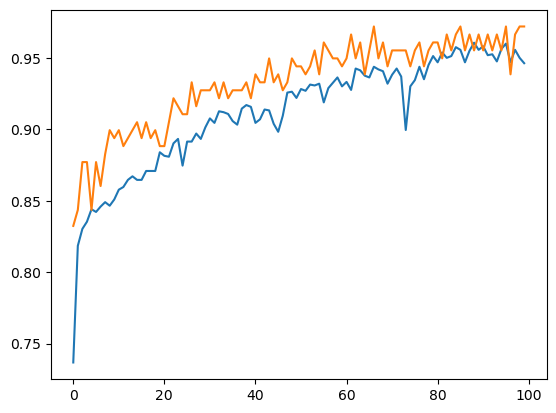

In [57]:
plt.plot(history.history['accuracy']) # gördüğü data
plt.plot(history.history['val_accuracy']) # görmediği data

accuracy:0.9562 BAŞARI ORANIYLA TİTANİC DATASINI DEEP LEARNING İLE ÇÖZÜLMÜŞTÜR.